
# Frozen External Validation — Alabama
## 10% sparse-observation, 3-hour physics-informed atmospheric thermal forecast

### Purpose

Oklahoma was used to discover the operating regime in which the frozen PINN appeared most useful:
**sparse temperature observations with a stronger advantage at +3 h**.

This notebook performs one external test in a different DigiCARES state and a separate heat episode.

> **Primary validation question:**  
> At 10% thermal-observation coverage, does the already-frozen PINN retain a meaningful advantage over the strongest baseline at +3 h in Central Alabama?

### Important rule

This is an **external validation**, not another model-development notebook.

The following are frozen from the successful Oklahoma formulation:

- pressure-coordinate potential-temperature advection–source PDE;
- 700/850/925 hPa levels;
- 12 h history;
- +1/+2/+3 h forecasts;
- 10% deterministic sparse sensor network;
- exact same sensor-selection algorithm and seed;
- same 4×64 tanh architecture;
- same constrained heating closure;
- same optimizer, training budgets, loss weights, collocation strategy, and causal schedule;
- same persistence, trend, coordinate-only NN, and forcing-aware NN baselines;
- same random seeds 101 and 202;
- same 4° outer buffer.

Only the **region and heat-event dates** change.

### Alabama event fixed before evaluation

Central Alabama had a documented heat episode on **July 27–28, 2026**.

National Weather Service Birmingham reported:
- July 27: dangerous heat indices around **105–109°F** across much of Central Alabama;
- July 28: a Heat Advisory for all of Central Alabama, again with maximum heat indices around **105–109°F**.

Official NWS sources:
- https://forecast.weather.gov/product.php?format=txt&glossary=0&issuedby=BMX&product=AFD&site=BMX&version=22
- https://forecast.weather.gov/showsigwx.php?lat=33.6325&lon=-86.8644&warncounty=ALC073&warnzone=ALZ024

### Predeclared primary endpoint

The **+3 h forecast** is the primary endpoint because Oklahoma identified that horizon before Alabama was evaluated.

External validation is considered supportive if:

1. mean +3 h PINN RMSE is at least **5% lower** than the strongest baseline; and
2. after averaging the two random seeds within each forecast origin, the PINN wins at **at least 3 of 4 origins**.

Seed-level +3 h win rate, +1/+2 h performance, and overall performance are reported as secondary diagnostics.

No Alabama result should be used to tune the model afterward.


In [ ]:
!pip install -q "cdsapi>=0.7.7" xarray netCDF4 h5netcdf scipy pandas matplotlib torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.8 MB/s eta 0:00:00


In [ ]:

import copy
import math
import os
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import RegularGridInterpolator, griddata
from scipy.ndimage import distance_transform_edt

import torch
import torch.nn as nn
from IPython.display import display

torch.set_default_dtype(torch.float32)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda



## CDS credential

For safety, this notebook does **not** copy the credential contained in the executed source notebook.

Either:
- set environment variable `CDSAPI_KEY`, or
- paste your CDS personal access token into the placeholder below.

Do not share the token in a paper, repository, screenshot, or public notebook.


In [ ]:

CDS_KEY = os.environ.get("CDSAPI_KEY", "").strip()

if not CDS_KEY:
    CDS_KEY = "PASTE_YOUR_CDS_KEY_HERE"

if CDS_KEY == "PASTE_YOUR_CDS_KEY_HERE":
    raise ValueError(
        "Set environment variable CDSAPI_KEY or paste your CDS key into CDS_KEY, then rerun this cell."
    )

with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write("url: https://cds.climate.copernicus.eu/api\n")
    f.write(f"key: {CDS_KEY}\n")

print("CDS credential configured.")


CDS credential configured.



## Frozen external-validation configuration

Leave `RUN_MODE="gate"` for the real scientific run.

The architecture/training/PDE configuration below is inherited from the successful Oklahoma 10% sparse experiment.  
Do **not** change hyperparameters based on Alabama results.


In [ ]:

EVENT_START = "2026-07-26"
EVENT_END   = "2026-07-29"

# Central Alabama external-validation evaluation domain.
EVAL_LAT_BOUNDS = (31.0, 34.5)
EVAL_LON_BOUNDS = (-88.5, -85.0)

# Large outer buffer. Future T is scored only in the inner domain.
BUFFER_DEG = 4.0
MODEL_LAT_BOUNDS = (EVAL_LAT_BOUNDS[0] - BUFFER_DEG, EVAL_LAT_BOUNDS[1] + BUFFER_DEG)
MODEL_LON_BOUNDS = (EVAL_LON_BOUNDS[0] - BUFFER_DEG, EVAL_LON_BOUNDS[1] + BUFFER_DEG)

PRESSURE_LEVELS_HPA = np.array([700.0, 850.0, 925.0])
P0_HPA = 1000.0

HISTORY_HOURS = 12
FORECAST_HOURS = 3
TREND_HOURS = 4

FORECAST_ORIGINS_GATE = [
    "2026-07-27 12:00:00",
    "2026-07-27 18:00:00",
    "2026-07-28 12:00:00",
    "2026-07-28 18:00:00",
]
SEEDS_GATE = [101, 202]

RUN_MODE = "gate"  # "gate" or "smoke"

# ---------------------------
# Phase 2B-1 sparse-observation gate
# ---------------------------
SENSOR_FRACTION = 0.10
SENSOR_SELECTION_SEED = 4242
MIN_SENSOR_COUNT = 25

# This gate intentionally uses one fixed spatial sensor network across all
# forecast origins and both random seeds.

if RUN_MODE == "smoke":
    FORECAST_ORIGINS = FORECAST_ORIGINS_GATE[:1]
    SEEDS = [101]
else:
    FORECAST_ORIGINS = FORECAST_ORIGINS_GATE
    SEEDS = SEEDS_GATE

SURFACE_PRESSURE_MARGIN_HPA = 20.0

HIDDEN = 64
LAYERS = 4

# Exact differentiable initial-field check.
EXACT_IC_GRID_RMSE_TOL_K = 2e-4

# Main models.
STAGE_A_STEPS = 1500
FUTURE_STAGE_STEPS = 1000
TOTAL_MAIN_STEPS = STAGE_A_STEPS + FORECAST_HOURS * FUTURE_STAGE_STEPS

DATA_BATCH = 4096
PHYS_BATCH = 2048
BOUNDARY_BATCH = 768

PAST_PHYS_POOL = 50000
FUTURE_PHYS_POOL = 50000
BOUNDARY_POOL = 15000

LEARNING_RATE = 1e-3
GRAD_CLIP = 5.0

LAMBDA_PHYSICS = 1.0
LAMBDA_BOUNDARY = 0.05
LAMBDA_SOURCE_REG = 1e-3

MAX_LATENT_SCALE = 2.0
MAX_B0_K_PER_H = 0.30
MAX_BP_K_PER_H = 0.30
MAX_DIURNAL_K_PER_H = 0.50

# Predeclared external-validation criteria.
# Practical confirmation criteria, not formal hypothesis-test thresholds.
PRIMARY_MIN_LEAD3_IMPROVEMENT_PCT = 5.0
PRIMARY_MIN_ORIGIN_WIN_RATE = 0.75

ERA5_FILE = "era5_external_alabama_jul26_29_2026_pressure.nc"
SURFACE_FILE = "era5_external_alabama_jul26_29_2026_surface.nc"

print("Run mode:", RUN_MODE)
print("Origins:", FORECAST_ORIGINS)
print("Seeds:", SEEDS)
print("Evaluation region:", EVAL_LAT_BOUNDS, EVAL_LON_BOUNDS)
print("Buffered model region:", MODEL_LAT_BOUNDS, MODEL_LON_BOUNDS)

print("Sensor fraction:", SENSOR_FRACTION)


Run mode: gate
Origins: ['2026-07-27 12:00:00', '2026-07-27 18:00:00', '2026-07-28 12:00:00', '2026-07-28 18:00:00']
Seeds: [101, 202]
Evaluation region: (31.0, 34.5) (-88.5, -85.0)
Buffered model region: (27.0, 38.5) (-92.5, -81.0)
Sensor fraction: 0.1



## Download ERA5 — Alabama external event

The data variables are exactly the same as in Oklahoma:

- temperature;
- horizontal wind \(u,v\);
- pressure vertical velocity \(\omega\);
- specific humidity \(q\);
- surface pressure for terrain masking.

The download region is the Central Alabama evaluation box plus the same **4° buffer** used previously.

Future temperature is never supplied to training. Future meteorological forcing remains known, so the experiment is a **conditional retrospective forecast / hindcast**, exactly as in Oklahoma.


In [ ]:

import cdsapi

days = pd.date_range(EVENT_START, EVENT_END, freq="D")
if days.to_period("M").nunique() != 1:
    raise ValueError("The requested event must stay within one calendar month.")

area = [
    MODEL_LAT_BOUNDS[1],
    MODEL_LON_BOUNDS[0],
    MODEL_LAT_BOUNDS[0],
    MODEL_LON_BOUNDS[1],
]
hours_req = [f"{h:02d}:00" for h in range(24)]

pressure_request = {
    "product_type": ["reanalysis"],
    "variable": [
        "temperature",
        "u_component_of_wind",
        "v_component_of_wind",
        "vertical_velocity",
        "specific_humidity",
    ],
    "pressure_level": [str(int(p)) for p in PRESSURE_LEVELS_HPA],
    "year": [days[0].strftime("%Y")],
    "month": [days[0].strftime("%m")],
    "day": [d.strftime("%d") for d in days],
    "time": hours_req,
    "area": area,
    "data_format": "netcdf",
    "download_format": "unarchived",
}

surface_request = {
    "product_type": ["reanalysis"],
    "variable": ["surface_pressure"],
    "year": [days[0].strftime("%Y")],
    "month": [days[0].strftime("%m")],
    "day": [d.strftime("%d") for d in days],
    "time": hours_req,
    "area": area,
    "data_format": "netcdf",
    "download_format": "unarchived",
}

client = cdsapi.Client()

if not Path(ERA5_FILE).exists():
    client.retrieve("reanalysis-era5-pressure-levels", pressure_request, ERA5_FILE)
    print("Saved:", ERA5_FILE)
else:
    print("Using existing:", ERA5_FILE)

if not Path(SURFACE_FILE).exists():
    client.retrieve("reanalysis-era5-single-levels", surface_request, SURFACE_FILE)
    print("Saved:", SURFACE_FILE)
else:
    print("Using existing:", SURFACE_FILE)


2026-09-12 03:36:14,449 INFO Request ID is c1c8e253-f1eb-4dfa-806b-f7741165c1b2
INFO:ecmwf.datastores.legacy_client:Request ID is c1c8e253-f1eb-4dfa-806b-f7741165c1b2
2026-09-12 03:36:14,673 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-12 03:36:54,205 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


46ab3754a4d1d1d53757769b85c14a79.nc:   0%|          | 0.00/6.31M [00:00<?, ?B/s]

Saved: era5_external_alabama_jul26_29_2026_pressure.nc


2026-09-12 03:36:58,425 INFO Request ID is dc282bc3-7c48-448a-9c96-c633dd8c6f4a
INFO:ecmwf.datastores.legacy_client:Request ID is dc282bc3-7c48-448a-9c96-c633dd8c6f4a
2026-09-12 03:36:58,605 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-12 03:37:22,283 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-12 03:37:33,872 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


4191af7f09f2620d4f8b2c09fab6f32b.nc:   0%|          | 0.00/328k [00:00<?, ?B/s]

Saved: era5_external_alabama_jul26_29_2026_surface.nc


## Load and standardize arrays

In [ ]:

def find_name(options, available, kind):
    for name in options:
        if name in available:
            return name
    raise KeyError(f"Could not find {kind}. Available: {list(available)}")

ds = xr.open_dataset(ERA5_FILE)

time_name = find_name(["valid_time", "time"], ds.coords, "time")
level_name = find_name(["pressure_level", "level"], ds.coords, "pressure")
lat_name = find_name(["latitude", "lat"], ds.coords, "latitude")
lon_name = find_name(["longitude", "lon"], ds.coords, "longitude")

T_name = find_name(["t", "temperature"], ds.data_vars, "temperature")
U_name = find_name(["u", "u_component_of_wind"], ds.data_vars, "u wind")
V_name = find_name(["v", "v_component_of_wind"], ds.data_vars, "v wind")
W_name = find_name(["w", "vertical_velocity"], ds.data_vars, "vertical velocity")
Q_name = find_name(["q", "specific_humidity"], ds.data_vars, "specific humidity")

ds = ds.sortby(time_name).sortby(level_name).sortby(lat_name).sortby(lon_name)

times = pd.to_datetime(ds[time_name].values)
levels = ds[level_name].values.astype(float)
lats = ds[lat_name].values.astype(float)
lons = ds[lon_name].values.astype(float)

if not np.allclose(levels, PRESSURE_LEVELS_HPA):
    raise ValueError(f"Expected pressure levels {PRESSURE_LEVELS_HPA}; found {levels}")

hours_from_start = np.asarray(
    (times - times[0]) / np.timedelta64(1, "h"),
    dtype=float,
)

def arr4(name):
    return ds[name].transpose(time_name, level_name, lat_name, lon_name).values.astype(np.float64)

T_K = arr4(T_name)
U_MS = arr4(U_name)
V_MS = arr4(V_name)
OMEGA_PA_S = arr4(W_name)
Q_SPEC = arr4(Q_name)

ds_sp = xr.open_dataset(SURFACE_FILE)
sp_time = find_name(["valid_time", "time"], ds_sp.coords, "surface time")
sp_lat = find_name(["latitude", "lat"], ds_sp.coords, "surface latitude")
sp_lon = find_name(["longitude", "lon"], ds_sp.coords, "surface longitude")
sp_name = find_name(["sp", "surface_pressure"], ds_sp.data_vars, "surface pressure")

ds_sp = ds_sp.sortby(sp_time).sortby(sp_lat).sortby(sp_lon)
SP_PA = ds_sp[sp_name].transpose(sp_time, sp_lat, sp_lon).values.astype(np.float64)

if SP_PA.shape != (len(times), len(lats), len(lons)):
    raise ValueError("Surface-pressure grid is not aligned with pressure-level grid.")

if not np.allclose(np.diff(hours_from_start), 1.0):
    raise ValueError("Expected exactly hourly ERA5 samples.")

print("Shape [time,p,lat,lon]:", T_K.shape)
print("Times:", times[0], "to", times[-1])
print("Levels:", levels)
print("Lat:", lats[0], "to", lats[-1])
print("Lon:", lons[0], "to", lons[-1])


Shape [time,p,lat,lon]: (96, 3, 47, 47)
Times: 2026-07-26 00:00:00 to 2026-07-29 23:00:00
Levels: [700. 850. 925.]
Lat: 27.0 to 38.5
Lon: -92.5 to -81.0



## Potential temperature and physical units

\[
\theta=T\left(\frac{1000}{p}\right)^{R_d/c_p}.
\]

The PDE is evaluated in:
- hours,
- km,
- hPa,
- K.

ERA5 \(\omega\) is in Pa/s, so \(1\ {\rm Pa/s}=36\ {\rm hPa/h}\).


In [ ]:

R_D = 287.05
C_P = 1004.0
L_V = 2.5e6
KAPPA = R_D / C_P

lat0 = 0.5 * (MODEL_LAT_BOUNDS[0] + MODEL_LAT_BOUNDS[1])
KM_PER_DEG_LAT = 111.0
KM_PER_DEG_LON = 111.0 * np.cos(np.radians(lat0))

x_km = (lons - np.mean(MODEL_LON_BOUNDS)) * KM_PER_DEG_LON
y_km = (lats - lat0) * KM_PER_DEG_LAT

exner_inverse = (P0_HPA / levels) ** KAPPA
THETA_K = T_K * exner_inverse[None, :, None, None]

U_KM_H = U_MS * 3.6
V_KM_H = V_MS * 3.6
OMEGA_HPA_H = OMEGA_PA_S * 36.0

T_roundtrip = THETA_K / exner_inverse[None, :, None, None]
roundtrip_err = float(np.nanmax(np.abs(T_roundtrip - T_K)))
assert roundtrip_err < 1e-10
assert np.isclose(36.0, 1.0 * 3600.0 / 100.0)

print("Potential-temperature round-trip max error:", roundtrip_err)
print("Omega conversion check: 1 Pa/s = 36 hPa/h")


Potential-temperature round-trip max error: 0.0
Omega conversion check: 1 Pa/s = 36 hPa/h



## Humidity-derived latent-heating proxy

\[
\frac{Dq}{Dt}=q_t+u q_x+v q_y+\omega q_p.
\]

Then
\[
Q_{\rm latent,T}= -\frac{L_v}{c_p}\frac{Dq}{Dt},
\]
and it is converted to potential-temperature tendency by \((1000/p)^\kappa\).


In [ ]:

Q_t = np.gradient(Q_SPEC, hours_from_start, axis=0, edge_order=2)
Q_p = np.gradient(Q_SPEC, levels, axis=1, edge_order=2)
Q_y = np.gradient(Q_SPEC, y_km, axis=2, edge_order=2)
Q_x = np.gradient(Q_SPEC, x_km, axis=3, edge_order=2)

DqDt = Q_t + U_KM_H * Q_x + V_KM_H * Q_y + OMEGA_HPA_H * Q_p
LATENT_T_K_H = -(L_V / C_P) * DqDt
LATENT_THETA_K_H = LATENT_T_K_H * exner_inverse[None, :, None, None]

print("Latent proxy finite fraction:", np.isfinite(LATENT_THETA_K_H).mean())
print("Latent proxy [1,50,99] percentiles K/h:",
      np.nanpercentile(LATENT_THETA_K_H, [1, 50, 99]))


Latent proxy finite fraction: 1.0
Latent proxy [1,50,99] percentiles K/h: [-4.20428105 -0.03394401  3.90871612]


## Forcing interpolators — no temperature target is included

In [ ]:

def interp4(field):
    return RegularGridInterpolator(
        (hours_from_start, levels, y_km, x_km),
        field,
        bounds_error=False,
        fill_value=np.nan,
    )

U_interp = interp4(U_KM_H)
V_interp = interp4(V_KM_H)
W_interp = interp4(OMEGA_HPA_H)
LAT_interp = interp4(LATENT_THETA_K_H)

SP_interp = RegularGridInterpolator(
    (hours_from_start, y_km, x_km),
    SP_PA / 100.0,
    bounds_error=False,
    fill_value=np.nan,
)

print("Forcing interpolators ready.")


Forcing interpolators ready.



## Sparse observation network, data preparation, and leakage guards

The sparse network is chosen using **geometry and surface-pressure validity only**—never temperature values.

A common horizontal sensor network is selected once for the entire Alabama external validation notebook:

1. identify horizontal cells that remain physically valid at all three pressure levels over every forecast origin and its 12-h history;
2. select 10% of those candidate cells using deterministic farthest-point sampling;
3. keep the same sensor locations for every origin and seed.

For each origin:

- past temperature labels are retained only at sensor locations;
- the \(t=0\) field is known only at sensor locations;
- a spatial background is reconstructed from those sparse \(t=0\) observations using linear interpolation with nearest-neighbor fallback;
- that sparse background is the common initial field for **all** learned methods and for persistence;
- local temperature trends are computed only at sensor locations and then interpolated spatially for the trend baseline;
- future full ERA5 temperature remains untouched until final evaluation.


Sparse sensor network: 213/2125 candidate cells = 10.02%


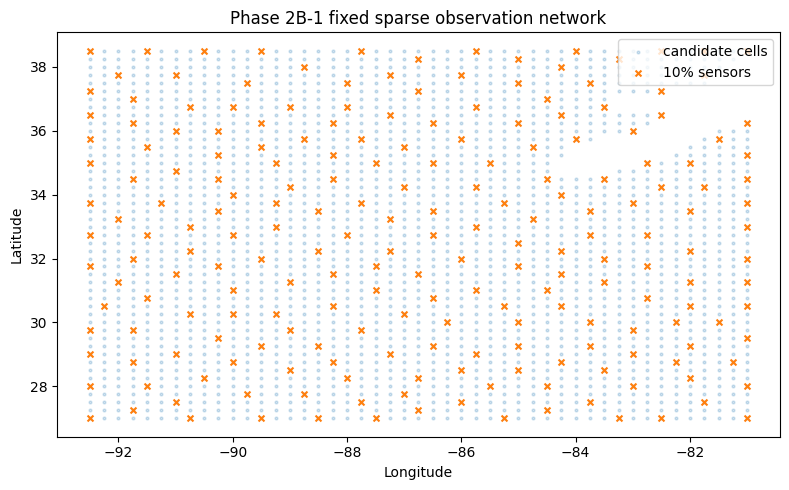

Sparse Phase 2B-1 data preparation is ready.


In [ ]:

def time_index_exact(timestamp):
    ts = pd.Timestamp(timestamp)
    hits = np.where(times == ts)[0]
    if len(hits) != 1:
        raise ValueError(f"Forecast origin {ts} is not exactly present.")
    return int(hits[0])


def valid_pressure_mask(time_idx, p_hpa):
    return (SP_PA[time_idx] / 100.0) >= (float(p_hpa) + SURFACE_PRESSURE_MARGIN_HPA)


lon2, lat2 = np.meshgrid(lons, lats)
x2_full, y2_full = np.meshgrid(x_km, y_km)
FULL_XY_POINTS = np.column_stack([x2_full.ravel(), y2_full.ravel()])

INNER_XY = (
    (lat2 >= EVAL_LAT_BOUNDS[0])
    & (lat2 <= EVAL_LAT_BOUNDS[1])
    & (lon2 >= EVAL_LON_BOUNDS[0])
    & (lon2 <= EVAL_LON_BOUNDS[1])
)


def utc_phase_from_abs_hour(abs_hour):
    base_hour = times[0].hour + times[0].minute/60.0 + times[0].second/3600.0
    hour_of_day = np.mod(base_hour + np.asarray(abs_hour), 24.0)
    angle = 2.0 * np.pi * hour_of_day / 24.0
    return np.sin(angle), np.cos(angle)


def farthest_point_sample(candidate_xy, n_select, seed):
    """
    Deterministic geometry-only sensor placement.
    Starts from a random candidate using a fixed seed, then repeatedly chooses
    the candidate farthest from the already-selected set.
    """
    candidate_xy = np.asarray(candidate_xy, dtype=float)
    n = len(candidate_xy)

    if n_select >= n:
        return np.arange(n, dtype=int)
    if n_select < 1:
        raise ValueError("n_select must be >= 1.")

    rng = np.random.default_rng(seed)
    first = int(rng.integers(0, n))

    selected = np.empty(n_select, dtype=int)
    selected[0] = first

    min_d2 = np.sum((candidate_xy - candidate_xy[first])**2, axis=1)
    min_d2[first] = -np.inf

    for k in range(1, n_select):
        idx = int(np.argmax(min_d2))
        selected[k] = idx
        d2 = np.sum((candidate_xy - candidate_xy[idx])**2, axis=1)
        min_d2 = np.minimum(min_d2, d2)
        min_d2[selected[:k+1]] = -np.inf

    return selected


def build_common_sensor_network():
    """
    Build one fixed horizontal sensor mask that is valid at all 3 pressure
    levels over all Phase-2B training histories and forecast origins.
    Uses surface pressure + geometry only.
    """
    relevant_time_indices = set()

    for origin in FORECAST_ORIGINS:
        oi = time_index_exact(origin)
        for it in range(oi - HISTORY_HOURS, oi + 1):
            relevant_time_indices.add(it)

    candidate = np.ones((len(lats), len(lons)), dtype=bool)

    for it in sorted(relevant_time_indices):
        for p in levels:
            candidate &= valid_pressure_mask(it, p)

    iy, ix = np.where(candidate)
    if len(iy) == 0:
        raise RuntimeError("No common physically valid sensor candidates.")

    candidate_xy = np.column_stack([x_km[ix], y_km[iy]])

    n_select = max(
        MIN_SENSOR_COUNT,
        int(np.ceil(SENSOR_FRACTION * len(candidate_xy)))
    )
    n_select = min(n_select, len(candidate_xy))

    chosen_local = farthest_point_sample(
        candidate_xy,
        n_select=n_select,
        seed=SENSOR_SELECTION_SEED,
    )

    sensor_mask = np.zeros_like(candidate, dtype=bool)
    sensor_mask[iy[chosen_local], ix[chosen_local]] = True

    return sensor_mask, candidate


SENSOR_MASK, SENSOR_CANDIDATE_MASK = build_common_sensor_network()

n_candidates = int(SENSOR_CANDIDATE_MASK.sum())
n_sensors = int(SENSOR_MASK.sum())

print(
    f"Sparse sensor network: {n_sensors}/{n_candidates} "
    f"candidate cells = {100*n_sensors/n_candidates:.2f}%"
)

# Geometry-only network visualization.
fig, ax = plt.subplots(figsize=(8, 5))
cy, cx = np.where(SENSOR_CANDIDATE_MASK)
sy, sx = np.where(SENSOR_MASK)
ax.scatter(lons[cx], lats[cy], s=4, alpha=0.20, label="candidate cells")
ax.scatter(lons[sx], lats[sy], s=18, marker="x", label="10% sensors")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Phase 2B-1 fixed sparse observation network")
ax.legend()
plt.tight_layout()
plt.show()


@dataclass
class OriginBundle:
    origin: pd.Timestamp
    origin_idx: int

    # Sparse labeled training data only.
    train_coords: np.ndarray
    train_theta: np.ndarray
    train_meta: np.ndarray
    train_forcing_extra: np.ndarray

    # Reconstructed sparse initial background on the full model grid.
    ic_xy: np.ndarray
    ic_background_levels: np.ndarray
    ic_valid_levels: np.ndarray

    # Sparse trend-slope background on the full model grid.
    trend_slope_levels: np.ndarray

    data_scale: float
    tendency_scale: float
    forcing_mean: np.ndarray
    forcing_std: np.ndarray

    past_phys: dict
    future_phys: dict
    future_boundary: dict


def build_grid_rows(time_indices, origin_idx, inner_only=False, sensor_only=False):
    coords_list, theta_list, meta_list, extra_list = [], [], [], []
    xy_selector = INNER_XY if inner_only else np.ones((len(lats), len(lons)), dtype=bool)

    if sensor_only:
        xy_selector = xy_selector & SENSOR_MASK

    for it in time_indices:
        tau = float(hours_from_start[it] - hours_from_start[origin_idx])
        s_t, c_t = utc_phase_from_abs_hour(hours_from_start[it])

        for ip, p in enumerate(levels):
            valid = (
                valid_pressure_mask(it, p)
                & valid_pressure_mask(origin_idx, p)
                & xy_selector
            )
            iy, ix = np.where(valid)
            if len(iy) == 0:
                continue

            n = len(iy)
            coords = np.column_stack([
                x_km[ix],
                y_km[iy],
                np.full(n, p),
                np.full(n, tau),
            ])

            theta = THETA_K[it, ip, iy, ix]

            meta = np.column_stack([
                np.full(n, it, dtype=int),
                np.full(n, ip, dtype=int),
                iy.astype(int),
                ix.astype(int),
            ])

            extra = np.column_stack([
                U_KM_H[it, ip, iy, ix],
                V_KM_H[it, ip, iy, ix],
                OMEGA_HPA_H[it, ip, iy, ix],
                Q_SPEC[it, ip, iy, ix],
                LATENT_THETA_K_H[it, ip, iy, ix],
                np.full(n, s_t),
                np.full(n, c_t),
            ])

            coords_list.append(coords)
            theta_list.append(theta)
            meta_list.append(meta)
            extra_list.append(extra)

    if not coords_list:
        raise RuntimeError("No rows were created for the requested grid/time selection.")

    return (
        np.concatenate(coords_list, axis=0),
        np.concatenate(theta_list, axis=0),
        np.concatenate(meta_list, axis=0),
        np.concatenate(extra_list, axis=0),
    )


def interpolate_sparse_to_full_grid(sensor_mask, values_2d, valid_target_mask):
    """
    Reconstruct a full 2D background using only sensor values.

    Linear interpolation is used where supported by the sensor convex hull;
    nearest-neighbor interpolation fills any remaining target cells.
    """
    sy, sx = np.where(sensor_mask)
    if len(sy) < 3:
        raise RuntimeError("Need at least 3 sensor points for 2D interpolation.")

    obs_xy = np.column_stack([x_km[sx], y_km[sy]])
    obs_values = values_2d[sy, sx]

    if not np.isfinite(obs_values).all():
        raise RuntimeError("Non-finite sparse observation encountered.")

    linear = griddata(
        obs_xy,
        obs_values,
        FULL_XY_POINTS,
        method="linear",
    ).reshape(len(lats), len(lons))

    nearest = griddata(
        obs_xy,
        obs_values,
        FULL_XY_POINTS,
        method="nearest",
    ).reshape(len(lats), len(lons))

    background = np.where(np.isfinite(linear), linear, nearest)

    # Values outside the physically valid target domain do not enter data loss
    # or evaluation at that pressure level; keep finite interpolation support
    # for autograd near terrain boundaries.
    if not np.isfinite(background).all():
        raise RuntimeError("Sparse interpolation produced non-finite background values.")

    return background


def build_sparse_initial_and_trend(origin_idx):
    """
    Build t=0 background and 4-hour trend from sparse sensor observations only.
    """
    bg_levels = []
    slope_levels = []
    valid_levels = []

    trend_idx = np.arange(origin_idx - TREND_HOURS + 1, origin_idx + 1)
    trend_tau = hours_from_start[trend_idx] - hours_from_start[origin_idx]
    tc = trend_tau - trend_tau.mean()
    denom = np.sum(tc**2)

    for ip, p in enumerate(levels):
        valid0 = valid_pressure_mask(origin_idx, p)

        # All selected sensors were constructed to be valid throughout the
        # relevant training histories, so these values are legitimate.
        theta0_grid = THETA_K[origin_idx, ip]
        bg = interpolate_sparse_to_full_grid(
            SENSOR_MASK,
            theta0_grid,
            valid0,
        )

        # Sensor-only temporal slope.
        hist = THETA_K[trend_idx, ip]  # [time,y,x]
        hist_mean = np.mean(hist, axis=0)
        slope_full_truth = np.sum(
            tc[:, None, None] * (hist - hist_mean[None, ...]),
            axis=0,
        ) / denom

        slope_bg = interpolate_sparse_to_full_grid(
            SENSOR_MASK,
            slope_full_truth,
            valid0,
        )

        bg_levels.append(bg)
        slope_levels.append(slope_bg)
        valid_levels.append(valid0)

    # [ncell, nlevel] format for compatibility with the existing initial-field code.
    bg_flat = np.column_stack([g.ravel() for g in bg_levels])
    valid_flat = np.column_stack([v.ravel() for v in valid_levels])

    return (
        FULL_XY_POINTS.copy(),
        bg_flat,
        valid_flat,
        np.stack(slope_levels, axis=0),
    )


def sample_collocation_pool(origin_idx, tau_low, tau_high, n_target, boundary=False, seed=0):
    rng = np.random.default_rng(seed)
    chunks = {k: [] for k in ["coords", "u", "v", "w", "latent", "sin", "cos"]}

    def current_n():
        return sum(len(a) for a in chunks["u"])

    attempts = 0
    while current_n() < n_target:
        attempts += 1
        if attempts > 100:
            raise RuntimeError("Unable to generate enough valid collocation points.")

        m = max(4096, n_target // 2)
        tau = rng.uniform(tau_low, tau_high, size=m)

        # Continuous pressure collocation, inherited from successful Phase 2A v3.
        p = rng.uniform(float(levels[0]), float(levels[-1]), size=m)

        if boundary:
            side = rng.integers(0, 4, size=m)
            x = rng.uniform(x_km[0], x_km[-1], size=m)
            y = rng.uniform(y_km[0], y_km[-1], size=m)
            x[side == 0] = x_km[0]
            x[side == 1] = x_km[-1]
            y[side == 2] = y_km[0]
            y[side == 3] = y_km[-1]
        else:
            x = rng.uniform(x_km[0], x_km[-1], size=m)
            y = rng.uniform(y_km[0], y_km[-1], size=m)

        abs_hour = hours_from_start[origin_idx] + tau
        pts4 = np.column_stack([abs_hour, p, y, x])
        pts3 = np.column_stack([abs_hour, y, x])
        pts3_0 = np.column_stack([
            np.full(m, hours_from_start[origin_idx]),
            y,
            x,
        ])

        sp_now = SP_interp(pts3)
        sp_0 = SP_interp(pts3_0)

        valid = (
            np.isfinite(sp_now)
            & np.isfinite(sp_0)
            & (sp_now >= p + SURFACE_PRESSURE_MARGIN_HPA)
            & (sp_0 >= p + SURFACE_PRESSURE_MARGIN_HPA)
        )
        if not valid.any():
            continue

        pts4_v = pts4[valid]
        u = U_interp(pts4_v)
        v = V_interp(pts4_v)
        w = W_interp(pts4_v)
        latent = LAT_interp(pts4_v)

        fv = np.isfinite(u) & np.isfinite(v) & np.isfinite(w) & np.isfinite(latent)
        if not fv.any():
            continue

        idx = np.where(valid)[0][fv]
        coords = np.column_stack([x[idx], y[idx], p[idx], tau[idx]])
        s_t, c_t = utc_phase_from_abs_hour(abs_hour[idx])

        chunks["coords"].append(coords)
        chunks["u"].append(u[fv])
        chunks["v"].append(v[fv])
        chunks["w"].append(w[fv])
        chunks["latent"].append(latent[fv])
        chunks["sin"].append(s_t)
        chunks["cos"].append(c_t)

    result = {k: np.concatenate(v, axis=0)[:n_target] for k, v in chunks.items()}

    forbidden = {"theta", "temperature", "target", "truth", "T"}
    assert forbidden.isdisjoint(result.keys())
    return result


def prepare_origin(origin, pool_seed=12345):
    oi = time_index_exact(origin)

    if oi - HISTORY_HOURS < 0:
        raise ValueError("Insufficient history.")
    if oi + FORECAST_HOURS >= len(times):
        raise ValueError("Insufficient future hours.")

    # Sparse temperature labels only.
    past_indices = list(range(oi - HISTORY_HOURS, oi))
    train_coords, train_theta, train_meta, train_extra = build_grid_rows(
        past_indices,
        oi,
        inner_only=False,
        sensor_only=True,
    )

    assert np.max(train_coords[:, 3]) < 0.0
    assert np.min(train_coords[:, 3]) >= -HISTORY_HOURS

    ic_xy, ic_background, ic_valid, trend_slope_levels = build_sparse_initial_and_trend(oi)

    # Compute scale using sparse training labels and sparse-background t0 values
    # at those same sensor locations.
    ip = train_meta[:, 1].astype(int)
    iy = train_meta[:, 2].astype(int)
    ix = train_meta[:, 3].astype(int)

    ic_bg_grid = np.stack(
        [
            ic_background[:, j].reshape(len(lats), len(lons))
            for j in range(len(levels))
        ],
        axis=0,
    )
    theta0_bg_at_train = ic_bg_grid[ip, iy, ix]
    data_scale = max(float(np.std(train_theta - theta0_bg_at_train)), 0.5)

    # Sparse-only temporal tendency scale.
    sparse_tendency_values = []
    for it in range(oi - HISTORY_HOURS, oi):
        next_it = it + 1
        for ip_, p in enumerate(levels):
            valid = (
                SENSOR_MASK
                & valid_pressure_mask(it, p)
                & valid_pressure_mask(next_it, p)
            )
            if valid.any():
                sparse_tendency_values.append(
                    (THETA_K[next_it, ip_] - THETA_K[it, ip_])[valid]
                )

    sparse_tendency_values = np.concatenate(sparse_tendency_values)
    tendency_scale = max(float(np.std(sparse_tendency_values)), 0.10)

    forcing_mean = np.nanmean(train_extra, axis=0)
    forcing_std = np.nanstd(train_extra, axis=0)
    forcing_std = np.where(forcing_std < 1e-8, 1.0, forcing_std)

    past_phys = sample_collocation_pool(
        oi, -HISTORY_HOURS, 0.0, PAST_PHYS_POOL,
        boundary=False, seed=pool_seed + oi
    )
    future_phys = sample_collocation_pool(
        oi, 0.0, FORECAST_HOURS, FUTURE_PHYS_POOL,
        boundary=False, seed=pool_seed + 1000 + oi
    )
    future_boundary = sample_collocation_pool(
        oi, 0.0, FORECAST_HOURS, BOUNDARY_POOL,
        boundary=True, seed=pool_seed + 2000 + oi
    )

    return OriginBundle(
        origin=pd.Timestamp(origin),
        origin_idx=oi,
        train_coords=train_coords,
        train_theta=train_theta,
        train_meta=train_meta,
        train_forcing_extra=train_extra,
        ic_xy=ic_xy,
        ic_background_levels=ic_background,
        ic_valid_levels=ic_valid,
        trend_slope_levels=trend_slope_levels,
        data_scale=data_scale,
        tendency_scale=tendency_scale,
        forcing_mean=forcing_mean,
        forcing_std=forcing_std,
        past_phys=past_phys,
        future_phys=future_phys,
        future_boundary=future_boundary,
    )


print("Sparse Phase 2B-1 data preparation is ready.")



## Differentiable sparse initial background

Unlike Phase 2A-R, Phase 2B does **not** use the full ERA5 \(t=0\) temperature field.

The initial field supplied to every learned model is the spatial interpolation of the 10% sparse sensor observations constructed above.

The existing differentiable bilinear initial-field object is retained, but it now interpolates the **sparse reconstructed background**, not full ERA5 truth.

A consistency test checks that the differentiable representation reproduces its own sparse-background grid to floating-point tolerance. This is a code check, not a comparison to hidden full \(t=0\) truth.


In [ ]:

class ExactInitialField(nn.Module):
    # Frozen bilinear interpolation of a supplied 3-level background grid.
    def __init__(self, level_grids):
        super().__init__()
        self.register_buffer("x_axis", torch.tensor(x_km, dtype=torch.float32))
        self.register_buffer("y_axis", torch.tensor(y_km, dtype=torch.float32))
        self.register_buffer("grids", torch.tensor(level_grids, dtype=torch.float32))

    def forward(self, xy):
        xq = torch.clamp(xy[:, 0], self.x_axis[0], self.x_axis[-1])
        yq = torch.clamp(xy[:, 1], self.y_axis[0], self.y_axis[-1])

        ix = torch.searchsorted(self.x_axis, xq, right=True) - 1
        iy = torch.searchsorted(self.y_axis, yq, right=True) - 1

        ix = torch.clamp(ix, 0, len(self.x_axis) - 2)
        iy = torch.clamp(iy, 0, len(self.y_axis) - 2)

        x0 = self.x_axis[ix]
        x1 = self.x_axis[ix + 1]
        y0 = self.y_axis[iy]
        y1 = self.y_axis[iy + 1]

        wx = ((xq - x0) / (x1 - x0)).unsqueeze(1)
        wy = ((yq - y0) / (y1 - y0)).unsqueeze(1)

        f00 = self.grids[:, iy,     ix    ].T
        f10 = self.grids[:, iy,     ix + 1].T
        f01 = self.grids[:, iy + 1, ix    ].T
        f11 = self.grids[:, iy + 1, ix + 1].T

        return (
            (1.0 - wx) * (1.0 - wy) * f00
            + wx * (1.0 - wy) * f10
            + (1.0 - wx) * wy * f01
            + wx * wy * f11
        )


def build_sparse_initial_field(bundle):
    level_grids = np.stack(
        [
            bundle.ic_background_levels[:, j].reshape(len(lats), len(lons))
            for j in range(len(levels))
        ],
        axis=0,
    )

    model = ExactInitialField(level_grids).to(device)
    model.eval()

    xy_t = torch.tensor(bundle.ic_xy, dtype=torch.float32, device=device)
    with torch.no_grad():
        pred = model(xy_t).cpu().numpy()

    truth_background = bundle.ic_background_levels
    err = pred - truth_background
    rmse_background = float(np.sqrt(np.mean(err**2)))

    print(f"    Sparse-background representation RMSE={rmse_background:.8f} K")

    if rmse_background > EXACT_IC_GRID_RMSE_TOL_K:
        raise RuntimeError(
            f"Sparse-background differentiable representation failed: "
            f"{rmse_background:.8f} K > {EXACT_IC_GRID_RMSE_TOL_K:.8f} K"
        )

    for par in model.parameters():
        par.requires_grad_(False)

    return model, rmse_background


## Anchored forecast models

In [ ]:
def make_mlp(in_dim, out_dim, hidden, layers):
    modules = [nn.Linear(in_dim, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        modules += [nn.Linear(hidden, hidden), nn.Tanh()]
    modules += [nn.Linear(hidden, out_dim)]
    return nn.Sequential(*modules)


def lagrange_weights(p):
    p0, p1, p2 = [float(v) for v in levels]
    L0 = (p-p1)*(p-p2)/((p0-p1)*(p0-p2))
    L1 = (p-p0)*(p-p2)/((p1-p0)*(p1-p2))
    L2 = (p-p0)*(p-p1)/((p2-p0)*(p2-p1))
    return torch.stack([L0,L1,L2], dim=1)

class AnchoredCoordinateModel(nn.Module):
    def __init__(self, ic_model, delta_scale):
        super().__init__()
        self.ic_model = ic_model
        self.delta_scale = float(delta_scale)
        self.xmin, self.xmax = float(x_km[0]), float(x_km[-1])
        self.ymin, self.ymax = float(y_km[0]), float(y_km[-1])
        self.pmin, self.pmax = float(levels[0]), float(levels[-1])
        self.net = make_mlp(4, 1, HIDDEN, LAYERS)

    def initial_theta(self, coords):
        vals = self.ic_model(coords[:,:2])
        return torch.sum(vals * lagrange_weights(coords[:,2]), dim=1)

    def norm_coords(self, coords):
        x = 2.0*(coords[:,0]-self.xmin)/(self.xmax-self.xmin)-1.0
        y = 2.0*(coords[:,1]-self.ymin)/(self.ymax-self.ymin)-1.0
        p = 2.0*(coords[:,2]-self.pmin)/(self.pmax-self.pmin)-1.0
        tau = coords[:,3] / HISTORY_HOURS
        return torch.stack([x,y,p,tau], dim=1)

    def forward(self, coords):
        base = self.initial_theta(coords)
        corr = self.net(self.norm_coords(coords)).squeeze(1)
        return base + (coords[:,3]/HISTORY_HOURS) * self.delta_scale * corr

class AnchoredForcingModel(nn.Module):
    def __init__(self, ic_model, delta_scale, forcing_mean, forcing_std):
        super().__init__()
        self.ic_model = ic_model
        self.delta_scale = float(delta_scale)
        self.xmin, self.xmax = float(x_km[0]), float(x_km[-1])
        self.ymin, self.ymax = float(y_km[0]), float(y_km[-1])
        self.pmin, self.pmax = float(levels[0]), float(levels[-1])
        self.register_buffer("fmean", torch.tensor(forcing_mean, dtype=torch.float32))
        self.register_buffer("fstd", torch.tensor(forcing_std, dtype=torch.float32))
        self.net = make_mlp(4+len(forcing_mean), 1, HIDDEN, LAYERS)

    def initial_theta(self, coords):
        vals = self.ic_model(coords[:,:2])
        return torch.sum(vals * lagrange_weights(coords[:,2]), dim=1)

    def norm_coords(self, coords):
        x = 2.0*(coords[:,0]-self.xmin)/(self.xmax-self.xmin)-1.0
        y = 2.0*(coords[:,1]-self.ymin)/(self.ymax-self.ymin)-1.0
        p = 2.0*(coords[:,2]-self.pmin)/(self.pmax-self.pmin)-1.0
        tau = coords[:,3] / HISTORY_HOURS
        return torch.stack([x,y,p,tau], dim=1)

    def forward(self, coords, extra):
        base = self.initial_theta(coords)
        z = torch.cat(
            [self.norm_coords(coords), (extra-self.fmean)/self.fstd],
            dim=1
        )
        corr = self.net(z).squeeze(1)
        return base + (coords[:,3]/HISTORY_HOURS) * self.delta_scale * corr

print("Anchored models ready.")


Anchored models ready.


## Heating closure and PINN residual

In [ ]:

class HeatingClosure(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_latent = nn.Parameter(torch.tensor(0.0))  # sigmoid -> alpha=1 initially
        self.raw_b0 = nn.Parameter(torch.tensor(0.0))
        self.raw_bp = nn.Parameter(torch.tensor(0.0))
        self.raw_bs = nn.Parameter(torch.tensor(0.0))
        self.raw_bc = nn.Parameter(torch.tensor(0.0))

    def coefficients(self):
        alpha = MAX_LATENT_SCALE * torch.sigmoid(self.raw_latent)
        b0 = MAX_B0_K_PER_H * torch.tanh(self.raw_b0)
        bp = MAX_BP_K_PER_H * torch.tanh(self.raw_bp)
        bs = MAX_DIURNAL_K_PER_H * torch.tanh(self.raw_bs)
        bc = MAX_DIURNAL_K_PER_H * torch.tanh(self.raw_bc)
        return alpha,b0,bp,bs,bc

    def source(self, p, latent, sin_t, cos_t):
        alpha,b0,bp,bs,bc = self.coefficients()
        p_star = (p-850.0)/150.0
        return alpha*latent + b0 + bp*p_star + bs*sin_t + bc*cos_t

    def regularization(self):
        _,b0,bp,bs,bc = self.coefficients()
        return (
            (b0/MAX_B0_K_PER_H)**2
            + (bp/MAX_BP_K_PER_H)**2
            + (bs/MAX_DIURNAL_K_PER_H)**2
            + (bc/MAX_DIURNAL_K_PER_H)**2
        )

def pool_to_tensors(pool):
    return {k: torch.tensor(v, dtype=torch.float32, device=device) for k,v in pool.items()}

def sample_pool_batch(pool_t, batch_size, tau_max=None):
    coords = pool_t["coords"]
    if tau_max is None:
        eligible = torch.arange(len(coords), device=device)
    else:
        eligible = torch.where(coords[:,3] <= float(tau_max)+1e-7)[0]
    if len(eligible) == 0:
        raise RuntimeError("No eligible pool points.")
    chosen = eligible[torch.randint(0, len(eligible), (min(batch_size, len(eligible)),), device=device)]
    return {k: v[chosen] for k,v in pool_t.items()}

def pde_residual(model, closure, batch):
    # coords are physical x[km], y[km], p[hPa], tau[h]
    coords = batch["coords"].clone().detach().requires_grad_(True)
    theta = model(coords)

    grads = torch.autograd.grad(
        theta, coords,
        grad_outputs=torch.ones_like(theta),
        create_graph=True,
    )[0]

    source = closure.source(
        coords[:,2], batch["latent"], batch["sin"], batch["cos"]
    )

    residual = (
        grads[:,3]
        + batch["u"] * grads[:,0]
        + batch["v"] * grads[:,1]
        + batch["w"] * grads[:,2]
        - source
    )
    return residual



## Manufactured-solution test
For \(	heta=a+Ax+By+Cp+Dt\), exact source is \(D+uA+vB+\omega C\). The implemented residual must be zero.


In [ ]:

class ManufacturedModel(nn.Module):
    def __init__(self, a,A,B,C,D):
        super().__init__()
        self.a,self.A,self.B,self.C,self.D = map(float,[a,A,B,C,D])
    def forward(self, coords):
        return (
            self.a
            + self.A*coords[:,0]
            + self.B*coords[:,1]
            + self.C*coords[:,2]
            + self.D*coords[:,3]
        )

class ManufacturedClosure(nn.Module):
    def __init__(self, exact_source):
        super().__init__()
        self.exact_source = float(exact_source)
    def source(self, p, latent, sin_t, cos_t):
        return torch.full_like(p, self.exact_source)

a,A,B,Cc,D = 300.0,0.01,-0.02,0.003,0.40
u0,v0,w0 = 25.0,-10.0,4.0
source0 = D + u0*A + v0*B + w0*Cc

coords_test = torch.tensor(
    [[0.0,0.0,850.0,1.0],
     [100.0,50.0,925.0,2.5],
     [-80.0,-40.0,700.0,-3.0]],
    dtype=torch.float32, device=device
)
batch_test = {
    "coords": coords_test,
    "u": torch.full((3,), u0, device=device),
    "v": torch.full((3,), v0, device=device),
    "w": torch.full((3,), w0, device=device),
    "latent": torch.zeros(3, device=device),
    "sin": torch.zeros(3, device=device),
    "cos": torch.zeros(3, device=device),
}

r = pde_residual(
    ManufacturedModel(a,A,B,Cc,D).to(device),
    ManufacturedClosure(source0).to(device),
    batch_test
).detach().cpu().numpy()

print("Manufactured residual:", r)
assert np.max(np.abs(r)) < 1e-5
print("MANUFACTURED PDE TEST PASSED.")


Manufactured residual: [0. 0. 0.]
MANUFACTURED PDE TEST PASSED.



## Buffer diagnostic
No future temperature boundary values are supplied. The outer boundary receives only a weak persistence penalty, while scoring is performed 4° inside. The notebook stops if the 99th-percentile 3-h wind displacement reaches the available horizontal buffer.


In [ ]:

buffer_y_km = BUFFER_DEG * KM_PER_DEG_LAT
buffer_x_km = BUFFER_DEG * KM_PER_DEG_LON
min_buffer_km = min(buffer_x_km, buffer_y_km)

origin_indices = [time_index_exact(o) for o in FORECAST_ORIGINS]
future_idx = sorted(set(
    j for oi in origin_indices
    for j in range(oi+1, oi+FORECAST_HOURS+1)
))

wind = np.sqrt(U_KM_H[future_idx]**2 + V_KM_H[future_idx]**2)
wind_q99 = float(np.nanpercentile(wind, 99))
disp_q99 = wind_q99 * FORECAST_HOURS

print(f"Minimum buffer: {min_buffer_km:.1f} km")
print(f"99th-percentile wind: {wind_q99:.1f} km/h")
print(f"3-h displacement: {disp_q99:.1f} km")

if disp_q99 >= min_buffer_km:
    raise RuntimeError(
        "3-h 99th-percentile advective displacement reaches/exceeds the buffer. "
        "Increase BUFFER_DEG before interpreting Phase 2A."
    )

print("BUFFER DIAGNOSTIC PASSED.")


Minimum buffer: 373.4 km
99th-percentile wind: 60.7 km/h
3-h displacement: 182.1 km
BUFFER DIAGNOSTIC PASSED.


## Baseline training

In [ ]:

def random_idx(n, batch_size):
    return torch.randint(0, n, (min(batch_size,n),), device=device)

def train_coordinate_baseline(bundle, ic_model, seed):
    set_seed(seed)
    model = AnchoredCoordinateModel(ic_model, bundle.data_scale).to(device)
    coords = torch.tensor(bundle.train_coords, dtype=torch.float32, device=device)
    target = torch.tensor(bundle.train_theta, dtype=torch.float32, device=device)

    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=TOTAL_MAIN_STEPS, eta_min=1e-5
    )

    for _ in range(TOTAL_MAIN_STEPS):
        idx = random_idx(len(coords), DATA_BATCH)
        pred = model(coords[idx])
        loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        sch.step()

    return model

def train_forcing_baseline(bundle, ic_model, seed):
    set_seed(seed + 10000)
    model = AnchoredForcingModel(
        ic_model, bundle.data_scale, bundle.forcing_mean, bundle.forcing_std
    ).to(device)

    coords = torch.tensor(bundle.train_coords, dtype=torch.float32, device=device)
    target = torch.tensor(bundle.train_theta, dtype=torch.float32, device=device)
    extra = torch.tensor(bundle.train_forcing_extra, dtype=torch.float32, device=device)

    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=TOTAL_MAIN_STEPS, eta_min=1e-5
    )

    for _ in range(TOTAL_MAIN_STEPS):
        idx = random_idx(len(coords), DATA_BATCH)
        pred = model(coords[idx], extra[idx])
        loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        sch.step()

    return model



## Causal PINN training
Stage A learns the network and low-dimensional closure using past labels and past physics. Then closure coefficients are frozen, and future unlabeled physics is expanded causally to +1 h, +2 h, and +3 h.


In [ ]:

def closure_values(closure):
    with torch.no_grad():
        return [float(v.detach().cpu()) for v in closure.coefficients()]

def train_pinn(bundle, ic_model, seed):
    set_seed(seed)

    model = AnchoredCoordinateModel(ic_model, bundle.data_scale).to(device)
    closure = HeatingClosure().to(device)

    coords = torch.tensor(bundle.train_coords, dtype=torch.float32, device=device)
    target = torch.tensor(bundle.train_theta, dtype=torch.float32, device=device)

    past_pool = pool_to_tensors(bundle.past_phys)
    future_pool = pool_to_tensors(bundle.future_phys)
    boundary_pool = pool_to_tensors(bundle.future_boundary)

    # Stage A: learn closure from past only.
    params = list(model.parameters()) + list(closure.parameters())
    opt = torch.optim.Adam(params, lr=LEARNING_RATE)

    for step in range(STAGE_A_STEPS):
        idx = random_idx(len(coords), DATA_BATCH)

        pred = model(coords[idx])
        data_loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

        pb = sample_pool_batch(past_pool, PHYS_BATCH)
        res = pde_residual(model, closure, pb)
        phys_loss = torch.mean((res/bundle.tendency_scale)**2)

        loss = (
            data_loss
            + LAMBDA_PHYSICS*phys_loss
            + LAMBDA_SOURCE_REG*closure.regularization()
        )

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
        opt.step()

        if step % 500 == 0:
            print(
                f"      Stage A {step:4d}/{STAGE_A_STEPS} "
                f"data={data_loss.item():.4f} physics={phys_loss.item():.4f}"
            )

    frozen_closure = closure_values(closure)
    for par in closure.parameters():
        par.requires_grad_(False)

    # Future causal stages.
    for horizon in range(1, FORECAST_HOURS+1):
        opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE*0.5)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=FUTURE_STAGE_STEPS, eta_min=1e-5
        )

        for _ in range(FUTURE_STAGE_STEPS):
            idx = random_idx(len(coords), DATA_BATCH)
            pred = model(coords[idx])
            data_loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

            pb0 = sample_pool_batch(past_pool, PHYS_BATCH//2)
            pbf = sample_pool_batch(future_pool, PHYS_BATCH//2, tau_max=horizon)

            r0 = pde_residual(model, closure, pb0)
            rf = pde_residual(model, closure, pbf)
            phys_loss = 0.5*(
                torch.mean((r0/bundle.tendency_scale)**2)
                + torch.mean((rf/bundle.tendency_scale)**2)
            )

            bb = sample_pool_batch(boundary_pool, BOUNDARY_BATCH, tau_max=horizon)
            theta_b = model(bb["coords"])
            theta_0 = model.initial_theta(bb["coords"])
            boundary_loss = torch.mean(((theta_b-theta_0)/bundle.data_scale)**2)

            loss = (
                data_loss
                + LAMBDA_PHYSICS*phys_loss
                + LAMBDA_BOUNDARY*boundary_loss
            )

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            sch.step()

        print(
            f"      Causal +{horizon}h complete | "
            f"data={data_loss.item():.4f}, physics={phys_loss.item():.4f}, "
            f"boundary={boundary_loss.item():.4f}"
        )

    # Closure must be bitwise unchanged after future stages.
    assert np.allclose(frozen_closure, closure_values(closure), atol=0, rtol=0)

    return model, closure



## Future evaluation helpers
**Future temperature truth is constructed only here, after model training for an origin.**


In [ ]:

def build_eval_bundle(bundle):
    oi = bundle.origin_idx
    future_indices = list(range(oi + 1, oi + FORECAST_HOURS + 1))

    # Full future ERA5 truth is used only here, for scoring.
    coords, theta_truth, meta, extra = build_grid_rows(
        future_indices,
        oi,
        inner_only=True,
        sensor_only=False,
    )

    ip = meta[:, 1].astype(int)
    iy = meta[:, 2].astype(int)
    ix = meta[:, 3].astype(int)
    tau = coords[:, 3]

    unique_tau = np.unique(tau)
    expected = np.arange(1, FORECAST_HOURS + 1, dtype=float)
    if not np.array_equal(unique_tau, expected):
        raise ValueError(f"Unexpected future lead times: {unique_tau}")

    # Sparse reconstructed t=0 background.
    bg_grid = np.stack(
        [
            bundle.ic_background_levels[:, j].reshape(len(lats), len(lons))
            for j in range(len(levels))
        ],
        axis=0,
    )
    persistence_theta = bg_grid[ip, iy, ix]

    # Sparse sensor-only trend field.
    trend_theta = (
        persistence_theta
        + bundle.trend_slope_levels[ip, iy, ix] * tau
    )

    return {
        "coords": coords,
        "theta_truth": theta_truth,
        "meta": meta,
        "extra": extra,
        "persistence_theta": persistence_theta,
        "trend_theta": trend_theta,
    }


def theta_to_T(theta, p_hpa):
    return theta / ((P0_HPA/p_hpa)**KAPPA)

def rmse(a,b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a,b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    return float(np.mean(np.abs(a-b)))

def corr(a,b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a,b)[0,1])

def predict_coord(model, coords):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0,len(coords),8192):
            c = torch.tensor(coords[s:s+8192], dtype=torch.float32, device=device)
            out.append(model(c).cpu().numpy())
    return np.concatenate(out)

def predict_forcing(model, coords, extra):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0,len(coords),8192):
            c = torch.tensor(coords[s:s+8192], dtype=torch.float32, device=device)
            e = torch.tensor(extra[s:s+8192], dtype=torch.float32, device=device)
            out.append(model(c,e).cpu().numpy())
    return np.concatenate(out)

def future_physics_rms(model, closure, bundle, seed=999):
    pool_t = pool_to_tensors(bundle.future_phys)
    rng = np.random.default_rng(seed)
    n = min(12000, len(bundle.future_phys["coords"]))
    idx_np = rng.choice(len(bundle.future_phys["coords"]), size=n, replace=False)
    idx = torch.tensor(idx_np, dtype=torch.long, device=device)
    sub = {k:v[idx] for k,v in pool_t.items()}
    res = pde_residual(model, closure, sub)
    return float(torch.sqrt(torch.mean(res**2)).detach().cpu())

print("Evaluation helpers ready.")


Evaluation helpers ready.



## Run the frozen Alabama external validation

For every forecast origin, all trainable models are completed **before future temperature truth is constructed**.

Do not alter the configuration after seeing Alabama outputs.


In [ ]:

rows = []
closure_rows = []
ic_rows = []

for no,origin in enumerate(FORECAST_ORIGINS, start=1):
    print("\n" + "="*90)
    print(f"ORIGIN {no}/{len(FORECAST_ORIGINS)}: {origin} UTC")
    print("="*90)

    bundle = prepare_origin(origin)

    print(
        f"  Past labels: {len(bundle.train_theta):,}; "
        f"tau={bundle.train_coords[:,3].min():.1f} to "
        f"{bundle.train_coords[:,3].max():.1f} h"
    )

    # Leakage guards.
    assert bundle.train_coords[:,3].max() < 0.0
    assert "theta" not in bundle.future_phys
    assert "temperature" not in bundle.future_phys

    print("  Building differentiable 10% sparse initial background...")
    ic_model, ic_rep_rmse = build_sparse_initial_field(bundle)

    ic_rows.append({
        "Origin": str(bundle.origin),
        "Sensor_Fraction": SENSOR_FRACTION,
        "N_Sensors": n_sensors,
        "Sparse_Background_Representation_RMSE_K": ic_rep_rmse,
        "N_Past_Temperature_Labels": len(bundle.train_theta),
    })

    trained = []

    for seed in SEEDS:
        print(f"\n  Seed {seed}")

        print("    matched coordinate-only NN")
        data_model = train_coordinate_baseline(bundle, ic_model, seed)

        print("    forcing-aware NN")
        forcing_model = train_forcing_baseline(bundle, ic_model, seed)

        print("    causal PINN")
        pinn_model, closure = train_pinn(bundle, ic_model, seed)

        alpha,b0,bp,bs,bc = closure_values(closure)
        phys_rms = future_physics_rms(pinn_model, closure, bundle)

        closure_rows.append({
            "Origin": str(bundle.origin),
            "Seed": seed,
            "latent_scale": alpha,
            "b0_K_per_h": b0,
            "bp_K_per_h": bp,
            "bs_K_per_h": bs,
            "bc_K_per_h": bc,
            "Future_Physics_RMS_K_per_h": phys_rms,
        })

        trained.append(
            (seed, data_model, forcing_model, pinn_model, closure, phys_rms)
        )

    # FUTURE TEMPERATURE TRUTH FIRST APPEARS AFTER TRAINING.
    ev = build_eval_bundle(bundle)

    coords_f = ev["coords"]
    p_f = coords_f[:,2]
    tau_f = coords_f[:,3]

    T_truth = theta_to_T(ev["theta_truth"], p_f)
    T_persist = theta_to_T(ev["persistence_theta"], p_f)
    T_trend = theta_to_T(ev["trend_theta"], p_f)

    for seed,data_model,forcing_model,pinn_model,closure,phys_rms in trained:
        T_data = theta_to_T(predict_coord(data_model, coords_f), p_f)
        T_force = theta_to_T(predict_forcing(forcing_model, coords_f, ev["extra"]), p_f)
        T_pinn = theta_to_T(predict_coord(pinn_model, coords_f), p_f)

        for lead in range(1,FORECAST_HOURS+1):
            m = np.isclose(tau_f, lead)

            r_persist = rmse(T_truth[m], T_persist[m])
            r_trend = rmse(T_truth[m], T_trend[m])
            r_data = rmse(T_truth[m], T_data[m])
            r_force = rmse(T_truth[m], T_force[m])
            r_pinn = rmse(T_truth[m], T_pinn[m])

            baseline = {
                "Persistence": r_persist,
                "Trend": r_trend,
                "MatchedDataNN": r_data,
                "ForcingAwareNN": r_force,
            }
            best_name = min(baseline, key=baseline.get)
            best_rmse = baseline[best_name]
            improvement = 100.0*(best_rmse-r_pinn)/best_rmse

            rows.append({
                "Origin": str(bundle.origin),
                "Sensor_Fraction": SENSOR_FRACTION,
                "N_Sensors": n_sensors,
                "Seed": seed,
                "Lead_h": lead,
                "N_eval": int(m.sum()),
                "Persistence_RMSE_K": r_persist,
                "Trend_RMSE_K": r_trend,
                "MatchedDataNN_RMSE_K": r_data,
                "ForcingAwareNN_RMSE_K": r_force,
                "PINN_RMSE_K": r_pinn,
                "Best_Baseline": best_name,
                "Best_Baseline_RMSE_K": best_rmse,
                "PINN_Improvement_vs_Best_pct": improvement,
                "PINN_MAE_K": mae(T_truth[m], T_pinn[m]),
                "PINN_Correlation": corr(T_truth[m], T_pinn[m]),
                "Future_Physics_RMS_K_per_h": phys_rms,
            })

    del trained
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results = pd.DataFrame(rows)
closures = pd.DataFrame(closure_rows)
ic_results = pd.DataFrame(ic_rows)

print("\nAll Phase-2A requested runs completed.")



ORIGIN 1/4: 2026-07-27 12:00:00 UTC
  Past labels: 7,668; tau=-12.0 to -1.0 h
  Building differentiable 10% sparse initial background...
    Sparse-background representation RMSE=0.00000882 K

  Seed 101
    matched coordinate-only NN
    forcing-aware NN
    causal PINN
      Stage A    0/1500 data=1.1863 physics=4.8031
      Stage A  500/1500 data=0.5328 physics=2.9224
      Stage A 1000/1500 data=0.3694 physics=1.4002
      Causal +1h complete | data=0.2516, physics=0.7354, boundary=0.0095
      Causal +2h complete | data=0.2394, physics=0.7037, boundary=0.0449
      Causal +3h complete | data=0.2024, physics=0.7819, boundary=0.0941

  Seed 202
    matched coordinate-only NN
    forcing-aware NN
    causal PINN
      Stage A    0/1500 data=1.3276 physics=4.1376
      Stage A  500/1500 data=0.5360 physics=2.4519
      Stage A 1000/1500 data=0.3839 physics=1.4206
      Causal +1h complete | data=0.2739, physics=0.8857, boundary=0.0133
      Causal +2h complete | data=0.2465, physics=


## Final results and predeclared external-validation decision

The primary Alabama endpoint is **+3 h**.

The decision is based on:
1. mean +3 h improvement versus the strongest baseline;
2. origin-level robustness after averaging over the two random seeds.

The remaining metrics are secondary diagnostics and must still be reported.


In [ ]:

display(results)

print("\nSparse-background diagnostics:")
display(ic_results)

print("\nClosure coefficients:")
display(closures)

mean_by_lead = results.groupby("Lead_h")[
    [
        "Persistence_RMSE_K",
        "Trend_RMSE_K",
        "MatchedDataNN_RMSE_K",
        "ForcingAwareNN_RMSE_K",
        "PINN_RMSE_K",
        "Best_Baseline_RMSE_K",
        "PINN_Improvement_vs_Best_pct",
    ]
].mean()

print("\nMean by lead:")
display(mean_by_lead)

lead3 = results[results["Lead_h"] == FORECAST_HOURS].copy()

lead3_mean_pinn = float(lead3["PINN_RMSE_K"].mean())
lead3_mean_best = float(lead3["Best_Baseline_RMSE_K"].mean())
lead3_improvement = 100.0 * (
    lead3_mean_best - lead3_mean_pinn
) / lead3_mean_best

lead3_seed_row_win_rate = float(
    (lead3["PINN_RMSE_K"] < lead3["Best_Baseline_RMSE_K"]).mean()
)

lead3_by_origin = (
    lead3.groupby("Origin")[
        ["PINN_RMSE_K", "Best_Baseline_RMSE_K"]
    ]
    .mean()
    .reset_index()
)

lead3_by_origin["PINN_Wins"] = (
    lead3_by_origin["PINN_RMSE_K"]
    < lead3_by_origin["Best_Baseline_RMSE_K"]
)

lead3_by_origin["Improvement_pct"] = 100.0 * (
    lead3_by_origin["Best_Baseline_RMSE_K"]
    - lead3_by_origin["PINN_RMSE_K"]
) / lead3_by_origin["Best_Baseline_RMSE_K"]

origin_win_rate = float(lead3_by_origin["PINN_Wins"].mean())

mean_pinn_all = float(results["PINN_RMSE_K"].mean())
mean_best_all = float(results["Best_Baseline_RMSE_K"].mean())
overall_improvement = 100.0 * (
    mean_best_all - mean_pinn_all
) / mean_best_all

overall_row_win_rate = float(
    (results["PINN_RMSE_K"] < results["Best_Baseline_RMSE_K"]).mean()
)

external_support = (
    lead3_improvement >= PRIMARY_MIN_LEAD3_IMPROVEMENT_PCT
    and origin_win_rate >= PRIMARY_MIN_ORIGIN_WIN_RATE
)

print("\n" + "="*88)
print("ALABAMA FROZEN EXTERNAL VALIDATION — PRIMARY +3 h ENDPOINT")
print("="*88)
print(f"+3 h mean PINN RMSE:                 {lead3_mean_pinn:.6f} K")
print(f"+3 h mean strongest-baseline RMSE:   {lead3_mean_best:.6f} K")
print(f"+3 h mean PINN improvement:          {lead3_improvement:+.3f}%")
print(f"+3 h seed-row win rate (supporting): {100*lead3_seed_row_win_rate:.1f}%")
print(f"+3 h origin-level win rate:          {100*origin_win_rate:.1f}%")

print("\n+3 h result by forecast origin (two seeds averaged):")
display(lead3_by_origin)

print("\nSecondary overall diagnostics:")
print(f"All-lead mean PINN RMSE:              {mean_pinn_all:.6f} K")
print(f"All-lead mean strongest baseline:     {mean_best_all:.6f} K")
print(f"All-lead PINN improvement:            {overall_improvement:+.3f}%")
print(f"All-lead row win rate:                {100*overall_row_win_rate:.1f}%")

print("\nPREDECLARED EXTERNAL-VALIDATION DECISION:")
if external_support:
    print(
        "SUPPORTIVE EXTERNAL VALIDATION: the frozen Alabama experiment confirms "
        "the Oklahoma-discovered +3 h sparse-observation regime under the "
        "predeclared practical criteria."
    )
else:
    print(
        "NOT SUPPORTIVE UNDER THE PREDECLARED CRITERIA. Do not tune Alabama, "
        "change the event, or search another state for a success. Report this "
        "as evidence that the Oklahoma PINN advantage is not yet regionally robust."
    )

results.to_csv("external_alabama_10pct_forecast_results.csv", index=False)
closures.to_csv("external_alabama_10pct_closure_coefficients.csv", index=False)
ic_results.to_csv("external_alabama_10pct_sparse_background_diagnostics.csv", index=False)
lead3_by_origin.to_csv("external_alabama_10pct_lead3_by_origin.csv", index=False)

print("\nSaved Alabama external-validation CSV outputs.")


,Origin,Sensor_Fraction,N_Sensors,Seed,Lead_h,N_eval,Persistence_RMSE_K,Trend_RMSE_K,MatchedDataNN_RMSE_K,ForcingAwareNN_RMSE_K,PINN_RMSE_K,Best_Baseline,Best_Baseline_RMSE_K,PINN_Improvement_vs_Best_pct,PINN_MAE_K,PINN_Correlation,Future_Physics_RMS_K_per_h
0,2026-07-27 12:00:00,0.1,213,101,1,675,0.562973,0.769429,0.647564,0.639226,0.460354,Persistence,0.562973,18.228121,0.350087,0.997413,0.345676
1,2026-07-27 12:00:00,0.1,213,101,2,675,0.886697,1.418309,1.102810,1.346670,0.725955,Persistence,0.886697,18.128199,0.570446,0.994863,0.345676
2,2026-07-27 12:00:00,0.1,213,101,3,675,1.040110,1.847363,1.299833,1.760432,0.870233,Persistence,1.040110,16.332596,0.637543,0.993836,0.345676
3,2026-07-27 12:00:00,0.1,213,202,1,675,0.562973,0.769429,0.623279,0.576713,0.474605,Persistence,0.562973,15.696727,0.360305,0.997208,0.350415
4,2026-07-27 12:00:00,0.1,213,202,2,675,0.886697,1.418309,1.058232,1.052131,0.739298,Persistence,0.886697,16.623323,0.566116,0.994564,0.350415
5,2026-07-27 12:00:00,0.1,213,202,3,675,1.040110,1.847363,1.273216,1.533150,0.878044,Persistence,1.040110,15.581640,0.632530,0.993866,0.350415
6,2026-07-27 18:00:00,0.1,213,101,1,675,0.636367,0.521460,0.430509,0.462866,0.430495,MatchedDataNN,0.430509,0.003213,0.342429,0.998365,0.466643
7,2026-07-27 18:00:00,0.1,213,101,2,675,1.012918,0.810816,0.793755,0.675304,0.592971,ForcingAwareNN,0.675304,12.191938,0.488802,0.997479,0.466643
8,2026-07-27 18:00:00,0.1,213,101,3,675,1.259778,1.031875,1.277294,1.106504,0.759027,Trend,1.031875,26.441962,0.615777,0.996054,0.466643
9,2026-07-27 18:00:00,0.1,213,202,1,675,0.636367,0.521460,0.434809,0.463999,0.444728,MatchedDataNN,0.434809,-2.281159,0.354952,0.998351,0.473545



Sparse-background diagnostics:


,Origin,Sensor_Fraction,N_Sensors,Sparse_Background_Representation_RMSE_K,N_Past_Temperature_Labels
0,2026-07-27 12:00:00,0.1,213,0.000009,7668
1,2026-07-27 18:00:00,0.1,213,0.000009,7668
2,2026-07-28 12:00:00,0.1,213,0.000009,7668
3,2026-07-28 18:00:00,0.1,213,0.000009,7668



Closure coefficients:


,Origin,Seed,latent_scale,b0_K_per_h,bp_K_per_h,bs_K_per_h,bc_K_per_h,Future_Physics_RMS_K_per_h
0,2026-07-27 12:00:00,101,0.513016,-0.086350,-0.081972,-0.094258,0.069448,0.345676
1,2026-07-27 12:00:00,202,0.507524,-0.088735,-0.080250,-0.089606,0.069471,0.350415
2,2026-07-27 18:00:00,101,0.496717,0.113902,-0.009137,-0.260067,0.207966,0.466643
3,2026-07-27 18:00:00,202,0.497453,0.110390,-0.006115,-0.259889,0.194613,0.473545
4,2026-07-28 12:00:00,101,0.497814,-0.067693,-0.131733,-0.068619,0.008521,0.362558
5,2026-07-28 12:00:00,202,0.497142,-0.072442,-0.131091,-0.066397,-0.001774,0.349566
6,2026-07-28 18:00:00,101,0.489989,0.087029,-0.024480,-0.217724,0.120782,0.500378
7,2026-07-28 18:00:00,202,0.499690,0.097346,-0.015477,-0.214868,0.140222,0.477684



Mean by lead:


,Persistence_RMSE_K,Trend_RMSE_K,MatchedDataNN_RMSE_K,ForcingAwareNN_RMSE_K,PINN_RMSE_K,Best_Baseline_RMSE_K,PINN_Improvement_vs_Best_pct
Lead_h,,,,,,,
1,0.479770,0.468280,0.415990,0.425909,0.373283,0.391398,2.496919
2,0.790686,0.841962,0.747909,0.764757,0.572969,0.645659,9.055426
3,1.000914,1.143804,1.115174,1.096276,0.690982,0.860434,16.759770



ALABAMA FROZEN EXTERNAL VALIDATION — PRIMARY +3 h ENDPOINT
+3 h mean PINN RMSE:                 0.690982 K
+3 h mean strongest-baseline RMSE:   0.860434 K
+3 h mean PINN improvement:          +19.694%
+3 h seed-row win rate (supporting): 75.0%
+3 h origin-level win rate:          75.0%

+3 h result by forecast origin (two seeds averaged):


,Origin,PINN_RMSE_K,Best_Baseline_RMSE_K,PINN_Wins,Improvement_pct
0,2026-07-27 12:00:00,0.874139,1.040110,True,15.957118
1,2026-07-27 18:00:00,0.744062,1.003895,True,25.882501
2,2026-07-28 12:00:00,0.549647,0.515320,False,-6.661168
3,2026-07-28 18:00:00,0.596079,0.882412,True,32.448881



Secondary overall diagnostics:
All-lead mean PINN RMSE:              0.545744 K
All-lead mean strongest baseline:     0.632497 K
All-lead PINN improvement:            +13.716%
All-lead row win rate:                62.5%

PREDECLARED EXTERNAL-VALIDATION DECISION:
SUPPORTIVE EXTERNAL VALIDATION: the frozen Alabama experiment confirms the Oklahoma-discovered +3 h sparse-observation regime under the predeclared practical criteria.

Saved Alabama external-validation CSV outputs.


## Visual summary — Alabama external validation

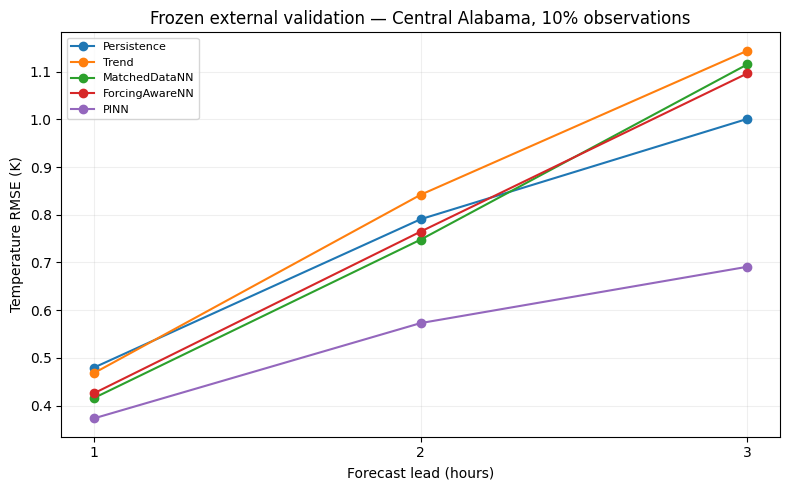

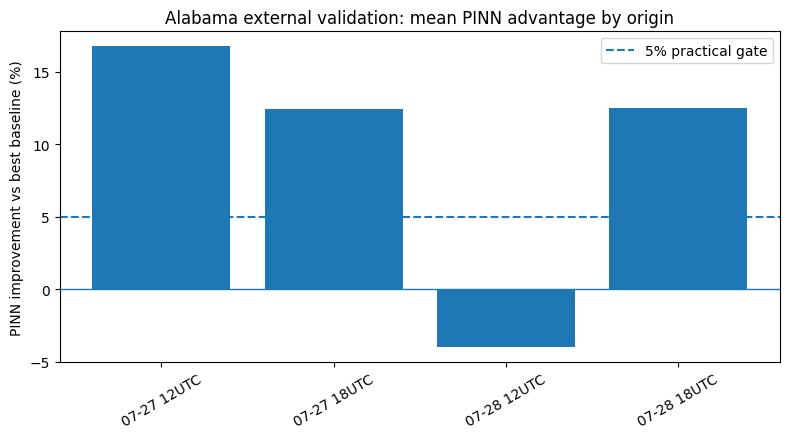

In [ ]:

plot_df = results.groupby("Lead_h")[
    [
        "Persistence_RMSE_K",
        "Trend_RMSE_K",
        "MatchedDataNN_RMSE_K",
        "ForcingAwareNN_RMSE_K",
        "PINN_RMSE_K",
    ]
].mean()

fig, ax = plt.subplots(figsize=(8,5))
for col in plot_df.columns:
    ax.plot(
        plot_df.index,
        plot_df[col],
        marker="o",
        label=col.replace("_RMSE_K",""),
    )
ax.set_xlabel("Forecast lead (hours)")
ax.set_ylabel("Temperature RMSE (K)")
ax.set_title("Frozen external validation — Central Alabama, 10% observations")
ax.set_xticks(range(1,FORECAST_HOURS+1))
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

origin_gain = results.groupby("Origin")["PINN_Improvement_vs_Best_pct"].mean()

fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(np.arange(len(origin_gain)), origin_gain.values)
ax.axhline(PRIMARY_MIN_LEAD3_IMPROVEMENT_PCT, linestyle="--", label="5% practical gate")
ax.axhline(0.0, linewidth=1)
ax.set_xticks(np.arange(len(origin_gain)))
ax.set_xticklabels(
    [pd.Timestamp(x).strftime("%m-%d %HUTC") for x in origin_gain.index],
    rotation=30,
)
ax.set_ylabel("PINN improvement vs best baseline (%)")
ax.set_title("Alabama external validation: mean PINN advantage by origin")
ax.legend()
plt.tight_layout()
plt.show()



## Interpretation rule — stop after this experiment

This Alabama run is the planned external validation.

### If supportive
Stop model experimentation and proceed to paper construction.

### If not supportive
Also stop model experimentation.

Do **not** tune the network on Alabama, change the event, alter the PDE after seeing the result, or search other states until one succeeds.

Instead, report:
- the Oklahoma operating regime;
- the Alabama non-confirmation;
- the conclusion that the physics advantage is regime-dependent rather than universally transferable.

Either outcome is scientifically interpretable.
